# Блок 6. Погружение в Python и анализ данных
## Занятие 11. Визуализация данных в Pandas и Matplotlib

### Цель занятия

Теперь данные уже можно:

- загружать;
- очищать;
- группировать;
- анализировать.

Следующий шаг — научиться представлять результаты в виде графиков.

### Что изучаем

- линейные графики;
- столбчатые диаграммы;
- гистограммы;
- диаграммы рассеяния;
- настройку графиков;
- визуальную аналитику.

### Датасет

California Housing

https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv

### Связь с дипломом

Практически каждый дипломный проект должен содержать графики и визуализацию результатов анализа.


Сначала изучите SOLVED-ноутбук, затем выполните TODO самостоятельно.

## Ячейка 1. Импорт библиотек

### Алгоритм

Подключаем pandas и matplotlib.

In [38]:
import pandas as pd
import matplotlib.pyplot as plt

assert pd is not None
assert plt is not None

## Ячейка 2. Загрузка датасета

### Алгоритм

Загружаем данные недвижимости.

In [39]:
url = "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/housing/housing.csv"
df = pd.read_csv(url)

print(df.shape)

assert len(df) > 0

(20640, 10)


## Ячейка 3. Первичное изучение

### Алгоритм

Смотрим первые строки и статистику.

In [40]:
display(df.head())
display(df.describe())

target_col = "median_house_value"
assert target_col in df.columns

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


## Ячейка 4. Гистограмма стоимости жилья

### Алгоритм

Строим распределение цен.

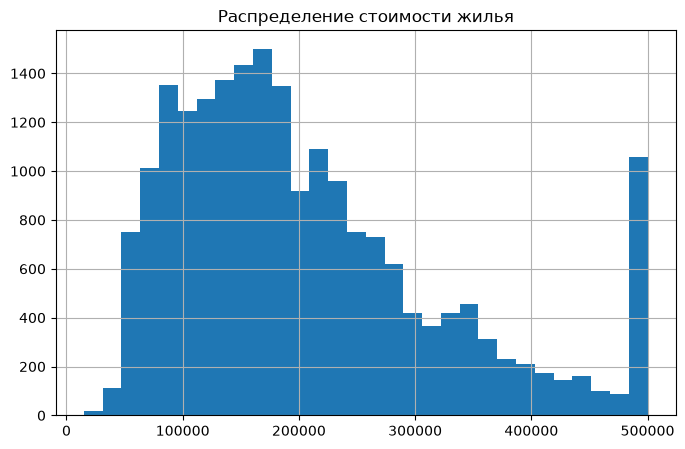

In [41]:
plt.figure(figsize=(8,5))
df[target_col].hist(bins=30)
plt.title("Распределение стоимости жилья")
plt.show()

## Ячейка 5. Гистограмма доходов

### Алгоритм

Анализируем доходы районов.

Text(0.5, 1.0, 'Распределение доходов')

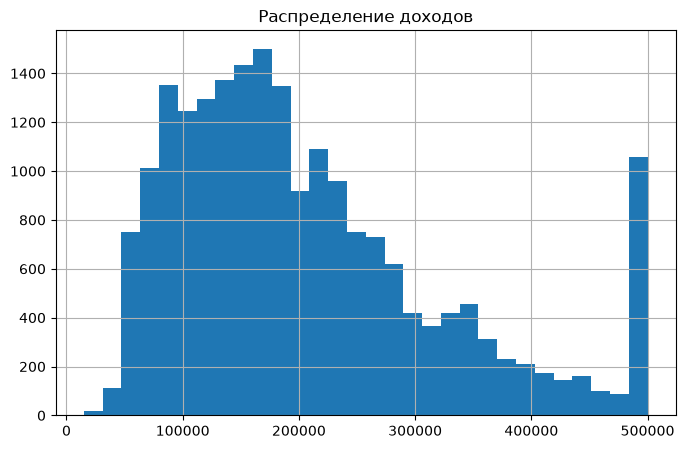

In [42]:
plt.figure(figsize=(8,5))
df[target_col].hist(bins=30)
plt.title("Распределение доходов")


## Ячейка 6. Столбчатая диаграмма

### Алгоритм

Средняя стоимость жилья по близости к океану.

<Axes: title={'center': 'Средняя стоимость жилья'}, xlabel='ocean_proximity'>

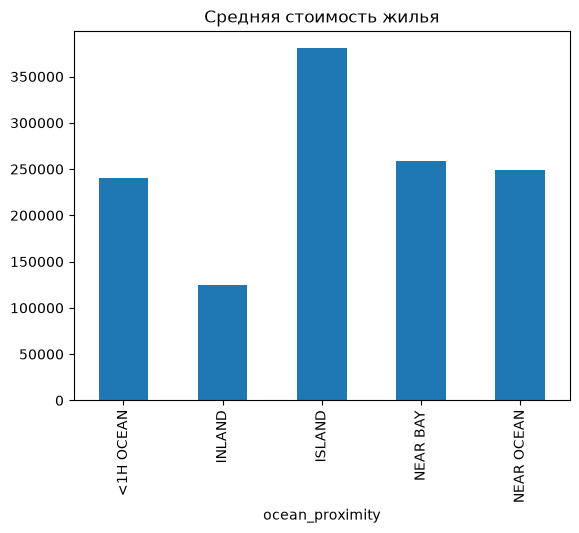

In [43]:
report = df.groupby("ocean_proximity")[target_col].mean()
report.plot(kind="bar", title="Средняя стоимость жилья")


## Ячейка 7. Диаграмма рассеяния

### Алгоритм

Доход против стоимости жилья.

Text(0, 0.5, 'Стоимость жилья')

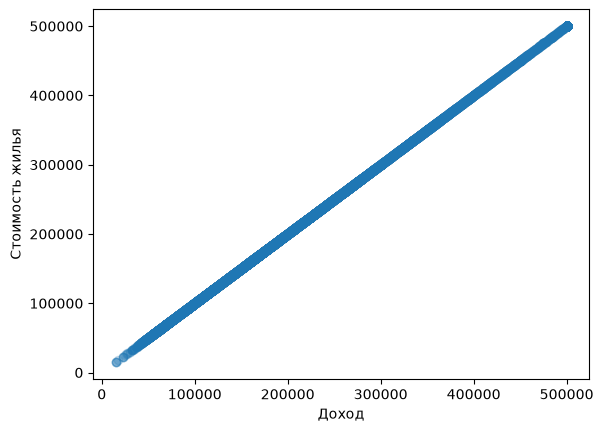

In [44]:
plt.scatter(df[target_col], df["median_house_value"], alpha=0.2)
plt.xlabel("Доход")
plt.ylabel("Стоимость жилья")



## Ячейка 8. Линейный график

### Алгоритм

Сортируем доходы и отображаем тренд.

Text(0.5, 1.0, 'Линейный график доходов')

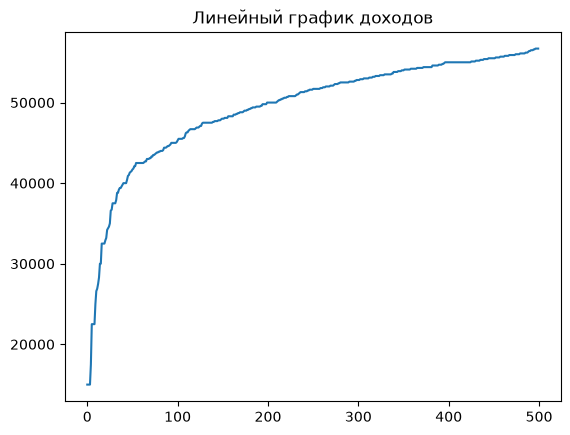

In [45]:
report = df[target_col].sort_values().reset_index(drop=True).head(500)

plt.plot(report)
plt.title("Линейный график доходов")


## Ячейка 9. Несколько графиков

### Алгоритм

Сравниваем распределения.

Text(0.5, 1.0, 'Возраст домов')

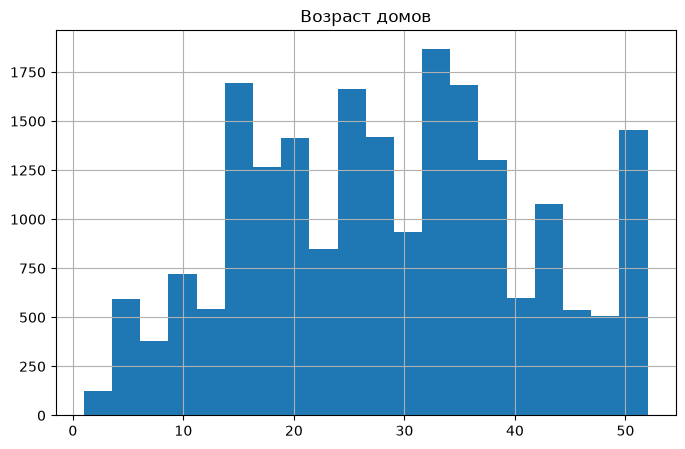

In [46]:
plt.figure(figsize=(8,5))
df["housing_median_age"].hist(bins=20)
plt.title("Возраст домов")

## Ячейка 10. Мини-проект визуализации

### Алгоритм

Создаем итоговый визуальный отчет.

In [47]:
summary = {
    "rows": len(df),
    "columns": len(df.columns),
    "avg_income": round(df["median_income"].mean(),2),
    "avg_house_value": round(df["median_house_value"].mean(),2)
}

print(summary)

assert summary["rows"] > 1000

{'rows': 20640, 'columns': 10, 'avg_income': np.float64(3.87), 'avg_house_value': np.float64(206855.82)}


# GitHub

Сделайте commit и push результатов занятия.